### Plot CSV Results


In [264]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

from pathlib import Path


In [265]:
route = Path("./results_df_edges.csv")

df_results = pd.read_csv(route)

In [266]:
df_results.head(2)

,algo,env_id,seed,runtime_sec,evals_total,U_best,curve_best,curve_mean,evals_cum,best_by_selectors,...,SCR,SFI,RBS,time_to_best,diversity_initial,diversity_final,delta_diversity,convergence_slope,runtime_efficiency,num_edges
0,flat,g10_high_0,11,81.242489,1800,229.68,"[42.05, 50.95, 61.18, 73.37, 80.07, 89.01, 100...","[-110.8336, -18.720399999999998, 27.2952000000...","[50, 85, 120, 155, 190, 225, 260, 295, 330, 36...",[],...,NaN,NaN,NaN,1765,60.609216,1.303457,-59.305759,10.536485,2.827092,31
1,flat,g10_high_0,17,80.039593,1800,224.40,"[47.05, 47.05, 56.99, 68.3, 72.35, 87.41, 100....","[-115.87580000000001, -41.0074, 1.705399999999...","[50, 85, 120, 155, 190, 225, 260, 295, 330, 36...",[],...,NaN,NaN,NaN,1800,57.468126,2.302199,-55.165927,7.741333,2.803612,31


In [267]:
df_results.columns

Index(['algo', 'env_id', 'seed', 'runtime_sec', 'evals_total', 'U_best',
       'curve_best', 'curve_mean', 'evals_cum', 'best_by_selectors',
       'pool_sizes', 'sizes', 'alphabet', 'N', 'density', 'max_depth',
       'price_file', 'SCR', 'SFI', 'RBS', 'time_to_best', 'diversity_initial',
       'diversity_final', 'delta_diversity', 'convergence_slope',
       'runtime_efficiency', 'num_edges'],
      dtype='object')

In [268]:
df_results['env_id'].unique()

array(['g10_high_0', 'g10_high_1', 'g10_high_2', 'g10_low_0', 'g10_low_1',
       'g10_low_2', 'g10_medium_0', 'g10_medium_1', 'g10_medium_2',
       'g14_high_0', 'g14_high_1', 'g14_high_2', 'g14_low_0', 'g14_low_1',
       'g14_low_2', 'g14_medium_0', 'g14_medium_1', 'g14_medium_2',
       'g18_high_0', 'g18_high_1', 'g18_high_2', 'g18_low_0', 'g18_low_1',
       'g18_low_2', 'g18_medium_0', 'g18_medium_1', 'g18_medium_2',
       'g22_low_0', 'g6_high_0', 'g6_high_1', 'g6_high_2', 'g6_low_0',
       'g6_low_1', 'g6_low_2', 'g6_medium_0', 'g6_medium_1',
       'g6_medium_2'], dtype=object)

In [269]:
# Step 1: filter by environment
env_to_filter = 'g6_medium_2'  # change to your env_id
df_env = df_results[df_results["env_id"] == env_to_filter]




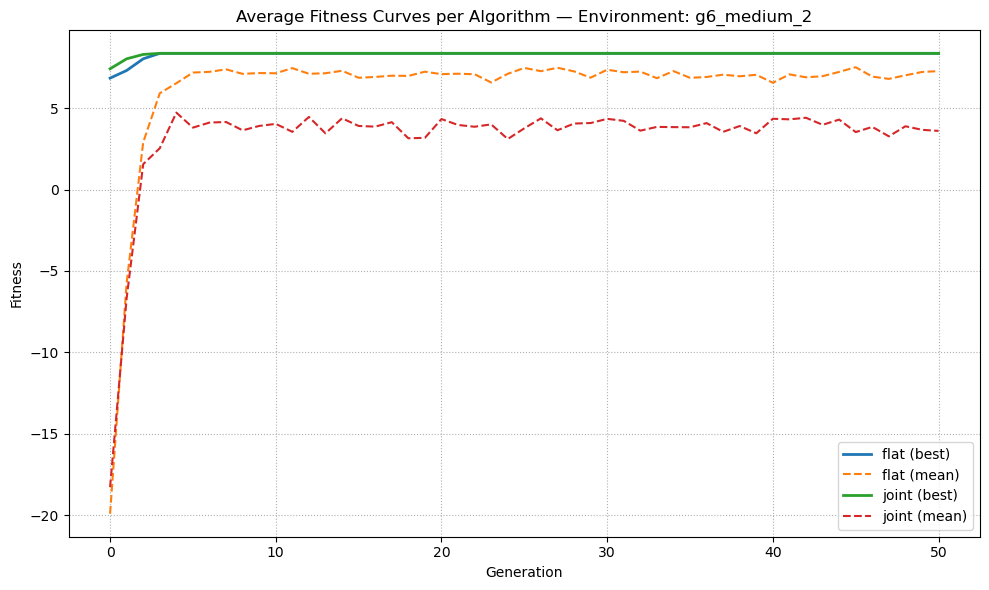

In [270]:
# Step 2: find unique algorithms
algos = df_env["algo"].unique()

# Step 3: unpack curve_best and curve_mean, average per generation
mean_curves_best = {}
mean_curves_mean = {}

for algo in algos:
    subset = df_env[df_env["algo"] == algo]

    # Convert list-like strings to actual lists if needed
    curves_best = subset["curve_best"].apply(lambda x: eval(x) if isinstance(x, str) else x)
    curves_mean = subset["curve_mean"].apply(lambda x: eval(x) if isinstance(x, str) else x)

    # Determine maximum generation length for padding
    max_len_best = max(len(c) for c in curves_best)
    max_len_mean = max(len(c) for c in curves_mean)
    max_len = max(max_len_best, max_len_mean)

    # Pad shorter runs with NaN to align
    padded_best = np.array([np.pad(c, (0, max_len - len(c)), constant_values=np.nan) for c in curves_best])
    padded_mean = np.array([np.pad(c, (0, max_len - len(c)), constant_values=np.nan) for c in curves_mean])

    # Compute means across runs, ignoring NaNs
    mean_curves_best[algo] = np.nanmean(padded_best, axis=0)
    mean_curves_mean[algo] = np.nanmean(padded_mean, axis=0)

# Step 4: plot all mean curves
plt.figure(figsize=(10, 6))

for algo in algos:
    plt.plot(
        range(len(mean_curves_best[algo])),
        mean_curves_best[algo],
        label=f"{algo} (best)",
        linewidth=2,
    )
    plt.plot(
        range(len(mean_curves_mean[algo])),
        mean_curves_mean[algo],
        linestyle="--",
        label=f"{algo} (mean)",
        linewidth=1.5,
    )

plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title(f"Average Fitness Curves per Algorithm — Environment: {env_to_filter}")
plt.legend()
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

In [271]:
df_results.columns

Index(['algo', 'env_id', 'seed', 'runtime_sec', 'evals_total', 'U_best',
       'curve_best', 'curve_mean', 'evals_cum', 'best_by_selectors',
       'pool_sizes', 'sizes', 'alphabet', 'N', 'density', 'max_depth',
       'price_file', 'SCR', 'SFI', 'RBS', 'time_to_best', 'diversity_initial',
       'diversity_final', 'delta_diversity', 'convergence_slope',
       'runtime_efficiency', 'num_edges'],
      dtype='object')

In [272]:
df_contour_plot = df_results[['env_id','algo','U_best','N','density','num_edges']]

In [273]:
df_contour_plot.head(5)

,env_id,algo,U_best,N,density,num_edges
0,g10_high_0,flat,229.68,10,0.75,31
1,g10_high_0,flat,224.40,10,0.75,31
2,g10_high_0,flat,228.63,10,0.75,31
3,g10_high_0,flat,225.46,10,0.75,31
4,g10_high_0,flat,228.63,10,0.75,31


In [274]:
df_contour_plot.columns

Index(['env_id', 'algo', 'U_best', 'N', 'density', 'num_edges'], dtype='object')

In [275]:
group_cols = ['env_id','algo']

In [276]:
# compute mean for all other numeric columns
df_contour_mean = df_contour_plot.groupby(group_cols, as_index=False).mean(numeric_only=True)

In [277]:
df_contour_mean

,env_id,algo,U_best,N,density,num_edges
0,g10_high_0,flat,227.43875,10.0,0.75,31.0
1,g10_high_0,joint,233.65250,10.0,0.75,31.0
2,g10_high_1,flat,10.31000,10.0,0.75,24.0
3,g10_high_1,joint,10.31000,10.0,0.75,24.0
4,g10_high_2,flat,-68.42875,10.0,0.75,29.0
...,...,...,...,...,...,...
69,g6_medium_0,joint,104.56000,6.0,0.50,10.0
70,g6_medium_1,flat,-19.47000,6.0,0.50,9.0
71,g6_medium_1,joint,-19.47000,6.0,0.50,9.0
72,g6_medium_2,flat,8.37000,6.0,0.50,7.0


diff = flat - join / worst 

In [278]:
pivot_df = df_contour_mean.pivot_table(
    index=['env_id', 'N', 'density','num_edges'],
    columns='algo',
    values='U_best'
).reset_index()

pivot_df[pivot_df['env_id'] == 'g18_medium_1'].head(6)

algo,env_id,N,density,num_edges,flat,joint
25,g18_medium_1,18.0,0.5,65.0,-3396.565,-3351.865


In [279]:
# Compute distance 


# Base formula: relative change in terms of 'flat'
pivot_df['diff_flat_minus_joint'] = (
    (pivot_df['joint'] - pivot_df['flat']) / pivot_df['flat'].abs()
) * 100


In [280]:
pivot_df

algo,env_id,N,density,num_edges,flat,joint,diff_flat_minus_joint
0,g10_high_0,10.0,0.75,31.0,227.43875,233.65250,2.732054
1,g10_high_1,10.0,0.75,24.0,10.31000,10.31000,0.000000
2,g10_high_2,10.0,0.75,29.0,-68.42875,-67.17000,1.839505
3,g10_low_0,10.0,0.25,11.0,-247.82000,-247.82000,0.000000
4,g10_low_1,10.0,0.25,10.0,-6.15000,-6.15000,0.000000
5,g10_low_2,10.0,0.25,12.0,74.84000,74.84000,0.000000
6,g10_medium_0,10.0,0.50,26.0,-354.41000,-354.41000,0.000000
7,g10_medium_1,10.0,0.50,21.0,-868.80000,-868.80000,0.000000
8,g10_medium_2,10.0,0.50,24.0,-180.67000,-180.67000,0.000000
9,g14_high_0,14.0,0.75,57.0,-3242.42625,-3224.24500,0.560730


In [281]:
# Step 3: Keep only relevant columns
contour_df = pivot_df[['env_id', 'diff_flat_minus_joint', 'N', 'density','num_edges']]

# Optional: sort by difference
contour_df = contour_df.sort_values('diff_flat_minus_joint', ascending=True)

In [282]:
contour_df

algo,env_id,diff_flat_minus_joint,N,density,num_edges
36,g6_medium_2,0.000000,6.0,0.50,7.0
28,g6_high_0,0.000000,6.0,0.75,9.0
27,g22_low_0,0.000000,22.0,0.25,45.0
23,g18_low_2,0.000000,18.0,0.25,34.0
22,g18_low_1,0.000000,18.0,0.25,32.0
21,g18_low_0,0.000000,18.0,0.25,32.0
31,g6_low_0,0.000000,6.0,0.25,6.0
32,g6_low_1,0.000000,6.0,0.25,6.0
35,g6_medium_1,0.000000,6.0,0.50,9.0
17,g14_medium_2,0.000000,14.0,0.50,35.0


In [283]:
contour_df.columns

Index(['env_id', 'diff_flat_minus_joint', 'N', 'density', 'num_edges'], dtype='object', name='algo')

In [284]:
contour_df['env_id'].unique().size

37

In [285]:
contour_df = contour_df[contour_df['env_id'] != 'g22_low_0']

In [286]:
contour_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36 entries, 36 to 11
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   env_id                 36 non-null     object 
 1   diff_flat_minus_joint  36 non-null     float64
 2   N                      36 non-null     float64
 3   density                36 non-null     float64
 4   num_edges              36 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.7+ KB


In [287]:
contour_df.head(2)

algo,env_id,diff_flat_minus_joint,N,density,num_edges
36,g6_medium_2,0.0,6.0,0.50,7.0
28,g6_high_0,0.0,6.0,0.75,9.0


In [288]:
contour_df['DAG_density'] = (2*contour_df['num_edges']) / (contour_df['N']*(contour_df['N']-1))

C:\Users\andre\AppData\Local\Temp\ipykernel_19480\3454189169.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contour_df['DAG_density'] = (2*contour_df['num_edges']) / (contour_df['N']*(contour_df['N']-1))


In [289]:
contour_df.head(2)

algo,env_id,diff_flat_minus_joint,N,density,num_edges,DAG_density
36,g6_medium_2,0.0,6.0,0.50,7.0,0.466667
28,g6_high_0,0.0,6.0,0.75,9.0,0.600000


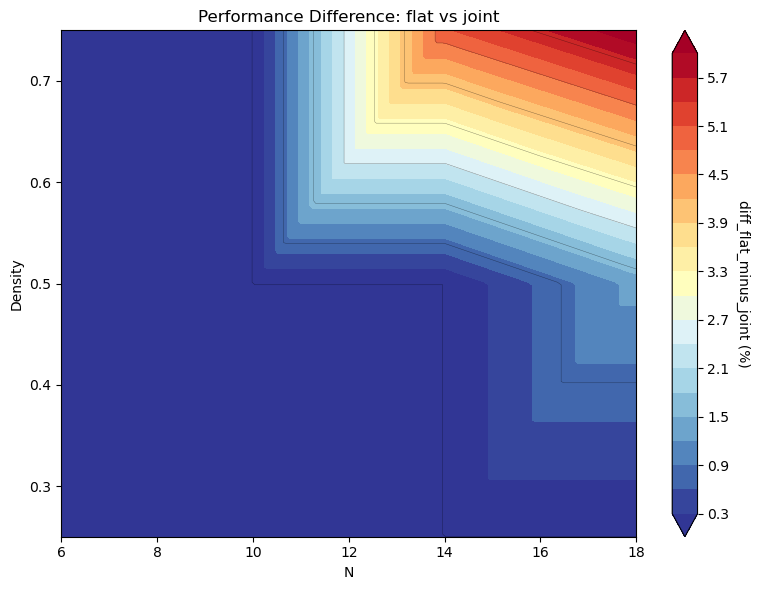

In [290]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import griddata

# Your columns
x = contour_df['N']
y = contour_df['density']
z = contour_df['diff_flat_minus_joint']

# Create a regular grid (same resolution)
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

#
Zi = griddata((x, y), z, (Xi, Yi), method='linear')

# Plot filled contours
plt.figure(figsize=(8, 6))
contour = plt.contourf(Xi, Yi, Zi, levels=20, cmap='RdYlBu_r', extend='both')
cbar = plt.colorbar(contour)
cbar.set_label('diff_flat_minus_joint (%)', rotation=270, labelpad=15)

# Optional: contour lines (for boundaries)
plt.contour(Xi, Yi, Zi, colors='k', linewidths=0.3, alpha=0.5)

plt.title('Performance Difference: flat vs joint')
plt.xlabel('N')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


In [291]:
df_results.columns

Index(['algo', 'env_id', 'seed', 'runtime_sec', 'evals_total', 'U_best',
       'curve_best', 'curve_mean', 'evals_cum', 'best_by_selectors',
       'pool_sizes', 'sizes', 'alphabet', 'N', 'density', 'max_depth',
       'price_file', 'SCR', 'SFI', 'RBS', 'time_to_best', 'diversity_initial',
       'diversity_final', 'delta_diversity', 'convergence_slope',
       'runtime_efficiency', 'num_edges'],
      dtype='object')

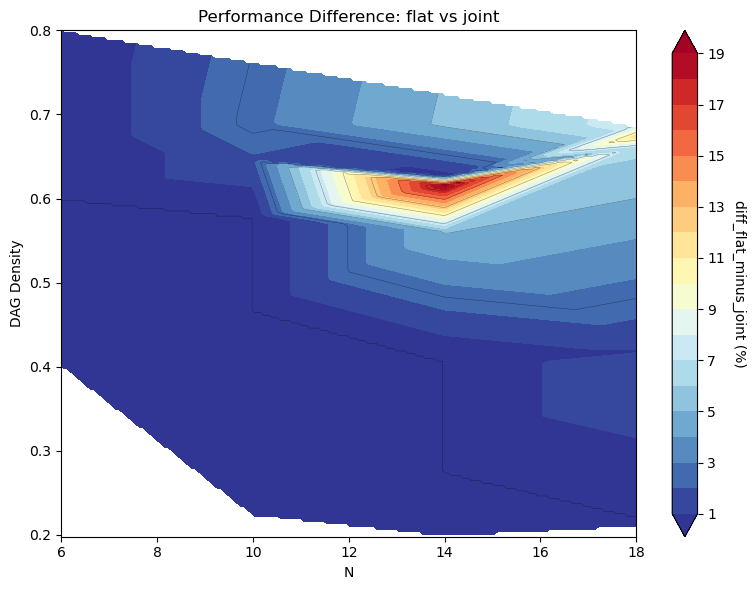

In [294]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import griddata

# Your columns
x = contour_df['N']
y = contour_df['DAG_density']
z = contour_df['diff_flat_minus_joint']

# Create a regular grid (same resolution)
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

#
Zi = griddata((x, y), z, (Xi, Yi), method='linear')

# Plot filled contours
plt.figure(figsize=(8, 6))
contour = plt.contourf(Xi, Yi, Zi, levels=20, cmap='RdYlBu_r', extend='both')
cbar = plt.colorbar(contour)
cbar.set_label('diff_flat_minus_joint (%)', rotation=270, labelpad=15)

# Optional: contour lines (for boundaries)
plt.contour(Xi, Yi, Zi, colors='k', linewidths=0.3, alpha=0.5)

plt.title('Performance Difference: flat vs joint')
plt.xlabel('N')
plt.ylabel('DAG Density')
plt.tight_layout()
plt.show()


In [295]:
df_results['Runtime per evaluation']=df_results['runtime_sec']/df_results['evals_total']

In [296]:
df_results['Runtime per evaluation'].max()

0.6143820531791616